In [12]:
import pandas as pd 
import numpy as np


In [34]:
patients = pd.read_csv("~/Desktop/2026-ASA-DataFest-Data-Files/patients.csv")
patients.head(10)

,CensusBlockGroupFipsCode,DurableKey,FirstRace,MaritalStatus,MyChartStatus,OmbEthnicity,OmbRace,SexAssignedAtBirth,SexualOrientation,SmokingStatus,VitalStatus,PatientBirthYearBin
0,201770007002,5.0,White or Caucasian,Single,Activated,Not Hispanic or Latino,White,*Unspecified,*Unspecified,Never,Alive,1970.0
1,*Unspecified,8.0,White or Caucasian,*Unspecified,Inactivated,Unknown,White,*Unspecified,*Unspecified,*Unknown,Alive,1980.0
2,*Unspecified,9.0,"Hispanic, Latino, or Spanish",Married,*Unspecified,Unknown,Some Other Race,*Unspecified,*Unspecified,Never,Alive,1955.0
3,*Unspecified,11.0,"Hispanic, Latino, or Spanish",Unknown,*Unspecified,Hispanic or Latino,Some Other Race,*Unspecified,*Unspecified,Never,Alive,1970.0
4,*Unspecified,12.0,Black or African American,Single,*Unspecified,Not Hispanic or Latino,Black or African American,*Unspecified,*Unspecified,Never,Alive,1980.0
5,*Unspecified,14.0,NaN,*Unspecified,*Unspecified,Unknown,Unknown,*Unspecified,*Unspecified,*Unknown,Alive,1995.0
6,201770030011,15.0,White or Caucasian,Single,Activated,Not Hispanic or Latino,White,*Unspecified,*Unspecified,Every Day,Alive,1985.0
7,200850826001,17.0,White or Caucasian,Married,Activated,Asked but No Answer,White,*Unspecified,*Unspecified,Never,Alive,1960.0
8,201770016032,19.0,White or Caucasian,Single,Pending Activation,Unknown,White,*Unspecified,*Unspecified,Never Assessed,Alive,2000.0
9,*Unspecified,21.0,White or Caucasian,*Unspecified,Inactivated,Unknown,White,*Unspecified,*Unspecified,*Unknown,Alive,1910.0


In [38]:
## dropping unnecessary columns

patients = patients[[
    'DurableKey',
    'PatientBirthYearBin',
    'SexAssignedAtBirth',
    'OmbRace',
    'OmbEthnicity',
    'SmokingStatus',
    'VitalStatus',
    'CensusBlockGroupFipsCode'
]]
patients.head(15)


,DurableKey,PatientBirthYearBin,SexAssignedAtBirth,OmbRace,OmbEthnicity,SmokingStatus,VitalStatus,CensusBlockGroupFipsCode
0,5.0,1970.0,*Unspecified,White,Not Hispanic or Latino,Never,Alive,201770007002
1,8.0,1980.0,*Unspecified,White,Unknown,*Unknown,Alive,*Unspecified
2,9.0,1955.0,*Unspecified,Some Other Race,Unknown,Never,Alive,*Unspecified
3,11.0,1970.0,*Unspecified,Some Other Race,Hispanic or Latino,Never,Alive,*Unspecified
4,12.0,1980.0,*Unspecified,Black or African American,Not Hispanic or Latino,Never,Alive,*Unspecified
5,14.0,1995.0,*Unspecified,Unknown,Unknown,*Unknown,Alive,*Unspecified
6,15.0,1985.0,*Unspecified,White,Not Hispanic or Latino,Every Day,Alive,201770030011
7,17.0,1960.0,*Unspecified,White,Asked but No Answer,Never,Alive,200850826001
8,19.0,2000.0,*Unspecified,White,Unknown,Never Assessed,Alive,201770016032
9,21.0,1910.0,*Unspecified,White,Unknown,*Unknown,Alive,*Unspecified


In [44]:
#Standardizing missing categories 
patients = patients.replace(['*Unspecified','Unknown','*Unknown'], np.nan)
patients.head()

,DurableKey,PatientBirthYearBin,SexAssignedAtBirth,OmbRace,OmbEthnicity,SmokingStatus,VitalStatus,CensusBlockGroupFipsCode
0,5.0,1970.0,NaN,White,Not Hispanic or Latino,Never,Alive,201770007002
1,8.0,1980.0,NaN,White,NaN,NaN,Alive,NaN
2,9.0,1955.0,NaN,Some Other Race,NaN,Never,Alive,NaN
3,11.0,1970.0,NaN,Some Other Race,Hispanic or Latino,Never,Alive,NaN
4,12.0,1980.0,NaN,Black or African American,Not Hispanic or Latino,Never,Alive,NaN


In [52]:
patients['DurableKey'].isna().sum()
patients['DurableKey'].duplicated().sum()

,DurableKey,PatientBirthYearBin,SexAssignedAtBirth,OmbRace,OmbEthnicity,SmokingStatus,VitalStatus,CensusBlockGroupFipsCode
0,5.0,1970.0,NaN,White,Not Hispanic or Latino,Never,Alive,201770007002
1,8.0,1980.0,NaN,White,NaN,NaN,Alive,NaN
2,9.0,1955.0,NaN,Some Other Race,NaN,Never,Alive,NaN
3,11.0,1970.0,NaN,Some Other Race,Hispanic or Latino,Never,Alive,NaN
4,12.0,1980.0,NaN,Black or African American,Not Hispanic or Latino,Never,Alive,NaN
...,...,...,...,...,...,...,...,...
947680,11135768.0,NaN,NaN,NaN,NaN,NaN,Alive,NaN
947681,11135771.0,NaN,NaN,NaN,NaN,NaN,Alive,NaN
947682,11135772.0,2005.0,NaN,NaN,NaN,NaN,Alive,NaN
947683,11135773.0,NaN,NaN,NaN,NaN,NaN,Alive,NaN


In [55]:
encounters = pd.read_csv("~/Desktop/2026-ASA-DataFest-Data-Files/encounters.csv")
encounters.head()

,Date,AdmissionInstant,AdmitYear,AdmitMonth,AdmitDay,AdmitHour,AdmitMinute,AdmissionSource,AdmissionType,DischargeInstant,...,AttendingProviderDurableKey,DischargeProviderDurableKey,DepartmentKey,PrimaryDiagnosisKey,IsEdVisit,IsHospitalAdmission,IsHospitalOutpatientVisit,IsInpatientAdmission,IsObservation,IsOutpatientFaceToFaceVisit
0,04/25/22,2022-04-25 20:33:00,2022.0,4.0,25.0,20.0,33.0,Non-Health Care Facility Point of Origin,Elective,2022-04-25 21:35:00,...,2982,2982,27,910699,0,1,0,0,1,0
1,04/29/22,2022-04-29 18:18:00,2022.0,4.0,29.0,18.0,18.0,Clinic/Physician Referral,Elective,2022-04-29 18:20:00,...,2979,2979,27,-1,0,1,0,0,1,0
2,01/10/22,2022-01-10 05:52:00,2022.0,1.0,10.0,5.0,52.0,Non-Health Care Facility Point of Origin,Elective,2022-01-12 11:43:00,...,6223,7015,27,468738,0,1,0,1,0,0
3,03/08/22,2022-03-08 09:08:00,2022.0,3.0,8.0,9.0,8.0,Non-Health Care Facility Point of Origin,Elective,2022-03-10 13:45:00,...,7973,7973,27,468492,0,1,0,1,0,0
4,03/16/22,2022-03-16 14:19:00,2022.0,3.0,16.0,14.0,19.0,Non-Health Care Facility Point of Origin,Elective,2022-03-16 16:00:00,...,6223,2982,27,907210,0,1,0,0,1,0


In [59]:
encounters['Date'] = pd.to_datetime(encounters['Date'])

,Date,AdmissionInstant,AdmitYear,AdmitMonth,AdmitDay,AdmitHour,AdmitMinute,AdmissionSource,AdmissionType,DischargeInstant,...,AttendingProviderDurableKey,DischargeProviderDurableKey,DepartmentKey,PrimaryDiagnosisKey,IsEdVisit,IsHospitalAdmission,IsHospitalOutpatientVisit,IsInpatientAdmission,IsObservation,IsOutpatientFaceToFaceVisit
0,2022-04-25,2022-04-25 20:33:00,2022.0,4.0,25.0,20.0,33.0,Non-Health Care Facility Point of Origin,Elective,2022-04-25 21:35:00,...,2982,2982,27,910699,0,1,0,0,1,0
1,2022-04-29,2022-04-29 18:18:00,2022.0,4.0,29.0,18.0,18.0,Clinic/Physician Referral,Elective,2022-04-29 18:20:00,...,2979,2979,27,-1,0,1,0,0,1,0
2,2022-01-10,2022-01-10 05:52:00,2022.0,1.0,10.0,5.0,52.0,Non-Health Care Facility Point of Origin,Elective,2022-01-12 11:43:00,...,6223,7015,27,468738,0,1,0,1,0,0
3,2022-03-08,2022-03-08 09:08:00,2022.0,3.0,8.0,9.0,8.0,Non-Health Care Facility Point of Origin,Elective,2022-03-10 13:45:00,...,7973,7973,27,468492,0,1,0,1,0,0
4,2022-03-16,2022-03-16 14:19:00,2022.0,3.0,16.0,14.0,19.0,Non-Health Care Facility Point of Origin,Elective,2022-03-16 16:00:00,...,6223,2982,27,907210,0,1,0,0,1,0


In [63]:
encounters_work = encounters[[
    'EncounterKey',
    'PatientDurableKey',
    'PrimaryDiagnosisKey',
    'Date',
    'AdmissionInstant',
    'DischargeInstant',
    'DepartmentKey',
    'ProviderDurableKey',
    'VisitTypeDescription',
    'IsEdVisit',
    'IsHospitalAdmission',
    'IsHospitalOutpatientVisit',
    'IsInpatientAdmission',
    'IsObservation',
    'IsOutpatientFaceToFaceVisit'
]].copy()
encounters_work.head()

,EncounterKey,PatientDurableKey,PrimaryDiagnosisKey,Date,AdmissionInstant,DischargeInstant,DepartmentKey,ProviderDurableKey,VisitTypeDescription,IsEdVisit,IsHospitalAdmission,IsHospitalOutpatientVisit,IsInpatientAdmission,IsObservation,IsOutpatientFaceToFaceVisit
0,7848127,86333,910699,2022-04-25,2022-04-25 20:33:00,2022-04-25 21:35:00,27,2982,*Unspecified,0,1,0,0,1,0
1,9333470,626973,-1,2022-04-29,2022-04-29 18:18:00,2022-04-29 18:20:00,27,2979,*Unspecified,0,1,0,0,1,0
2,29444575,236044,468738,2022-01-10,2022-01-10 05:52:00,2022-01-12 11:43:00,27,6223,*Unspecified,0,1,0,1,0,0
3,30915704,385246,468492,2022-03-08,2022-03-08 09:08:00,2022-03-10 13:45:00,27,7973,*Unspecified,0,1,0,1,0,0
4,33223911,353096,907210,2022-03-16,2022-03-16 14:19:00,2022-03-16 16:00:00,27,6223,*Unspecified,0,1,0,0,1,0


In [65]:
encounters_work[['PatientDurableKey','PrimaryDiagnosisKey','Date']].isna().sum()

PatientDurableKey      0
PrimaryDiagnosisKey    0
Date                   0
dtype: int64

In [67]:
encounters_work['PatientDurableKey'].isin(patients['DurableKey']).mean()

0.9580265303907697

In [69]:
encounters_work['VisitTypeDescription'] = encounters['VisitTypeDescription'].replace(
    ['*Unspecified','Unknown','Not Specified'],
    np.nan
)
encounters_work.head()

,EncounterKey,PatientDurableKey,PrimaryDiagnosisKey,Date,AdmissionInstant,DischargeInstant,DepartmentKey,ProviderDurableKey,VisitTypeDescription,IsEdVisit,IsHospitalAdmission,IsHospitalOutpatientVisit,IsInpatientAdmission,IsObservation,IsOutpatientFaceToFaceVisit
0,7848127,86333,910699,2022-04-25,2022-04-25 20:33:00,2022-04-25 21:35:00,27,2982,NaN,0,1,0,0,1,0
1,9333470,626973,-1,2022-04-29,2022-04-29 18:18:00,2022-04-29 18:20:00,27,2979,NaN,0,1,0,0,1,0
2,29444575,236044,468738,2022-01-10,2022-01-10 05:52:00,2022-01-12 11:43:00,27,6223,NaN,0,1,0,1,0,0
3,30915704,385246,468492,2022-03-08,2022-03-08 09:08:00,2022-03-10 13:45:00,27,7973,NaN,0,1,0,1,0,0
4,33223911,353096,907210,2022-03-16,2022-03-16 14:19:00,2022-03-16 16:00:00,27,6223,NaN,0,1,0,0,1,0


In [71]:
diagnosis = pd.read_csv("~/Desktop/2026-ASA-DataFest-Data-Files/diagnosis.csv")
diagnosis.head()

,DiagnosisKey,GroupName,GroupCode,DiagnosisName,DiagnosisValue
0,2.0,Typhoid and paratyphoid fevers,ICD-10-CM: A01,"Paratyphoid fever, unspecified( ICD-10-CM: A01...",A01.4
1,3.0,Respiratory tuberculosis,ICD-10-CM: A15,Primary respiratory tuberculosis( ICD-10-CM: A...,A15.7
2,7.0,Fracture at wrist and hand level,ICD-10-CM: S62,"Displaced fracture of pisiform, unspecified wr...",S62.163K
3,8.0,Fracture of rib,ICD-10-CM: S22,"Multiple fractures of ribs, right side, subseq...",S22.41XG
4,9.0,Fracture at wrist and hand level,ICD-10-CM: S62,Nondisplaced fracture of distal phalanx of lef...,S62.663G


In [77]:
diagnosis['DiagnosisKey'].isna().sum()
diagnosis['DiagnosisKey'].duplicated().sum()

148707

In [85]:
diagnosis = diagnosis.drop_duplicates(subset='DiagnosisKey')
diagnosis['DiagnosisKey'].duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 1382555 entries, 0 to 1531261
Data columns (total 5 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DiagnosisKey    1382555 non-null  float64
 1   GroupName       1382555 non-null  object 
 2   GroupCode       1382555 non-null  object 
 3   DiagnosisName   1382555 non-null  object 
 4   DiagnosisValue  1382555 non-null  object 
dtypes: float64(1), object(4)
memory usage: 63.3+ MB


In [89]:
encounters_work['PrimaryDiagnosisKey'].isin(diagnosis['DiagnosisKey']).mean()

0.7942429721666833

In [91]:
encounters_work[~encounters_work['PrimaryDiagnosisKey'].isin(diagnosis['DiagnosisKey'])]['PrimaryDiagnosisKey'].nunique()

1

In [93]:
diagnosis = diagnosis.rename(columns={
'DiagnosisKey':'diagnosis_id',
'GroupName':'diagnosis_group',
'DiagnosisName':'diagnosis_name'
})
diagnosis.head()

,diagnosis_id,diagnosis_group,GroupCode,diagnosis_name,DiagnosisValue
0,2.0,Typhoid and paratyphoid fevers,ICD-10-CM: A01,"Paratyphoid fever, unspecified( ICD-10-CM: A01...",A01.4
1,3.0,Respiratory tuberculosis,ICD-10-CM: A15,Primary respiratory tuberculosis( ICD-10-CM: A...,A15.7
2,7.0,Fracture at wrist and hand level,ICD-10-CM: S62,"Displaced fracture of pisiform, unspecified wr...",S62.163K
3,8.0,Fracture of rib,ICD-10-CM: S22,"Multiple fractures of ribs, right side, subseq...",S22.41XG
4,9.0,Fracture at wrist and hand level,ICD-10-CM: S62,Nondisplaced fracture of distal phalanx of lef...,S62.663G


In [95]:
master = encounters_work.merge(
    diagnosis,
    left_on='PrimaryDiagnosisKey',
    right_on='diagnosis_id',
    how='left'
)


In [97]:
master = master.merge(
    patients,
    left_on='PatientDurableKey',
    right_on='DurableKey',
    how='left'
)

In [103]:
master.head()
master.isna().sum()

EncounterKey                         0
PatientDurableKey                    0
PrimaryDiagnosisKey                  0
Date                                 0
AdmissionInstant               6627001
DischargeInstant               6627001
DepartmentKey                        0
ProviderDurableKey                   0
VisitTypeDescription           1213827
IsEdVisit                            0
IsHospitalAdmission                  0
IsHospitalOutpatientVisit            0
IsInpatientAdmission                 0
IsObservation                        0
IsOutpatientFaceToFaceVisit          0
diagnosis_id                   1579350
diagnosis_group                1579350
GroupCode                      1579350
diagnosis_name                 1579350
DiagnosisValue                 1579350
DurableKey                      322180
PatientBirthYearBin             323170
SexAssignedAtBirth             5322431
OmbRace                         509466
OmbEthnicity                    641341
SmokingStatus            

In [107]:
master.to_csv("~/Desktop/2026-ASA-DataFest-Data-Files/master_cleaned.csv", index=False)

In [111]:
journeys = master.groupby(
    ['PatientDurableKey','PrimaryDiagnosisKey']
).agg(
    visits=('EncounterKey','count'),
    first_visit=('Date','min'),
    last_visit=('Date','max')
).reset_index()
journeys.head()

,PatientDurableKey,PrimaryDiagnosisKey,visits,first_visit,last_visit
0,5,-1,4,2025-07-16,2025-09-15
1,5,385080,1,2025-09-05,2025-09-05
2,5,517473,1,2025-10-03,2025-10-03
3,5,583220,2,2025-10-21,2025-10-21
4,5,619745,1,2025-11-06,2025-11-06


In [115]:
journeys['journey_days'] = (
    journeys['last_visit'] - journeys['first_visit']
).dt.days
journeys.head()

,PatientDurableKey,PrimaryDiagnosisKey,visits,first_visit,last_visit,journey_days
0,5,-1,4,2025-07-16,2025-09-15,61
1,5,385080,1,2025-09-05,2025-09-05,0
2,5,517473,1,2025-10-03,2025-10-03,0
3,5,583220,2,2025-10-21,2025-10-21,0
4,5,619745,1,2025-11-06,2025-11-06,0


In [121]:
master = master.sort_values([
'PatientDurableKey',
'PrimaryDiagnosisKey',
'Date'
])

master['gap_days'] = master.groupby(
['PatientDurableKey','PrimaryDiagnosisKey']
)['Date'].diff().dt.days

In [123]:
gap_stats = master.groupby(
['PatientDurableKey','PrimaryDiagnosisKey']
).agg(
    avg_gap=('gap_days','mean'),
    max_gap=('gap_days','max')
).reset_index()
gap_stats.head()

,PatientDurableKey,PrimaryDiagnosisKey,avg_gap,max_gap
0,5,-1,20.333333,35.0
1,5,385080,NaN,NaN
2,5,517473,NaN,NaN
3,5,583220,0.000000,0.0
4,5,619745,NaN,NaN


In [125]:
journeys = journeys.merge(
gap_stats,
on=['PatientDurableKey','PrimaryDiagnosisKey'],
how='left'
)
journeys.head()

,PatientDurableKey,PrimaryDiagnosisKey,visits,first_visit,last_visit,journey_days,avg_gap,max_gap
0,5,-1,4,2025-07-16,2025-09-15,61,20.333333,35.0
1,5,385080,1,2025-09-05,2025-09-05,0,NaN,NaN
2,5,517473,1,2025-10-03,2025-10-03,0,NaN,NaN
3,5,583220,2,2025-10-21,2025-10-21,0,0.000000,0.0
4,5,619745,1,2025-11-06,2025-11-06,0,NaN,NaN


In [137]:
dept_counts = master.groupby(
['PatientDurableKey','PrimaryDiagnosisKey']
)['DepartmentKey'].nunique().reset_index()

dept_counts = dept_counts.rename(
columns={'DepartmentKey':'num_departments'}
)

journeys = journeys.merge(
dept_counts,
on=['PatientDurableKey','PrimaryDiagnosisKey'],
how='left'
)

In [139]:
ed_counts = master.groupby(
['PatientDurableKey','PrimaryDiagnosisKey']
)['IsEdVisit'].sum().reset_index()

ed_counts = ed_counts.rename(
columns={'IsEdVisit':'ed_visits'}
)

journeys = journeys.merge(
ed_counts,
on=['PatientDurableKey','PrimaryDiagnosisKey'],
how='left'
)

In [143]:
journeys.head(20)

,PatientDurableKey,PrimaryDiagnosisKey,visits,first_visit,last_visit,journey_days,avg_gap,max_gap,num_departments,ed_visits
0,5,-1,4,2025-07-16,2025-09-15,61,20.333333,35.0,1,0
1,5,385080,1,2025-09-05,2025-09-05,0,NaN,NaN,1,0
2,5,517473,1,2025-10-03,2025-10-03,0,NaN,NaN,1,0
3,5,583220,2,2025-10-21,2025-10-21,0,0.000000,0.0,2,0
4,5,619745,1,2025-11-06,2025-11-06,0,NaN,NaN,1,0
5,5,964723,1,2025-07-02,2025-07-02,0,NaN,NaN,1,0
6,5,1537083,1,2025-11-06,2025-11-06,0,NaN,NaN,1,0
7,9,-1,1,2024-11-04,2024-11-04,0,NaN,NaN,1,0
8,9,24782,1,2024-05-28,2024-05-28,0,NaN,NaN,1,0
9,9,345369,1,2024-10-15,2024-10-15,0,NaN,NaN,1,0


In [155]:
journeys[['avg_gap','max_gap','journey_days']].describe()
journeys.sort_values('avg_gap', ascending=False).head(20)
journeys['delayed'] = journeys['avg_gap'] > 60
journeys['delayed'].value_counts(normalize=True)

delayed
False    0.829637
True     0.170363
Name: proportion, dtype: float64

In [157]:
journeys.groupby('delayed')[[
'visits',
'journey_days',
'num_departments',
'ed_visits'
]].mean()

,visits,journey_days,num_departments,ed_visits
delayed,,,,
False,1.945575,18.654295,1.243446,0.083857
True,3.951308,594.801753,1.807075,0.048951


In [161]:
journeys.groupby('delayed')['visits'].mean()

delayed
False    1.945575
True     3.951308
Name: visits, dtype: float64

In [163]:
journeys.groupby('delayed')['num_departments'].mean()

delayed
False    1.243446
True     1.807075
Name: num_departments, dtype: float64

In [165]:
journeys.groupby('delayed')['ed_visits'].mean()

delayed
False    0.083857
True     0.048951
Name: ed_visits, dtype: float64

In [181]:
journeys = journeys.merge(
patients[['DurableKey','PatientBirthYearBin']],
left_on='PatientDurableKey',
right_on='DurableKey',
how='left'
)
journeys.head()

,PatientDurableKey,PrimaryDiagnosisKey,visits,first_visit,last_visit,journey_days,avg_gap,max_gap,num_departments,ed_visits,ed_flag,delayed,DurableKey_x,PatientBirthYearBin_x,DurableKey_y,PatientBirthYearBin_y
0,5,-1,4,2025-07-16,2025-09-15,61,20.333333,35.0,1,0,False,False,5.0,1970.0,5.0,1970.0
1,5,385080,1,2025-09-05,2025-09-05,0,NaN,NaN,1,0,False,False,5.0,1970.0,5.0,1970.0
2,5,517473,1,2025-10-03,2025-10-03,0,NaN,NaN,1,0,False,False,5.0,1970.0,5.0,1970.0
3,5,583220,2,2025-10-21,2025-10-21,0,0.000000,0.0,2,0,False,False,5.0,1970.0,5.0,1970.0
4,5,619745,1,2025-11-06,2025-11-06,0,NaN,NaN,1,0,False,False,5.0,1970.0,5.0,1970.0


In [185]:
journeys.groupby('PatientBirthYearBin_x')['avg_gap'].mean().sort_values()

PatientBirthYearBin_x
1905.0     11.068966
2025.0     24.837005
1915.0     95.991994
1995.0    110.688280
2000.0    113.307018
1990.0    117.264751
2020.0    123.464707
1985.0    127.166016
1980.0    140.583388
1925.0    146.631878
2005.0    147.913461
1975.0    149.111546
1920.0    149.515748
1930.0    151.942258
1970.0    152.371861
1965.0    152.918004
1935.0    154.577971
1955.0    155.488800
1960.0    156.141311
1940.0    157.316074
1945.0    159.602978
1950.0    162.994047
1900.0    164.002897
2010.0    204.076448
2015.0    236.062188
1850.0           NaN
1890.0           NaN
1910.0           NaN
Name: avg_gap, dtype: float64

In [187]:
journeys.groupby('PatientBirthYearBin_x')['delayed'].mean().sort_values()

PatientBirthYearBin_x
1850.0    0.000000
1890.0    0.000000
1910.0    0.000000
1905.0    0.000000
2025.0    0.033358
2000.0    0.103443
1995.0    0.111946
2005.0    0.114390
2020.0    0.121678
1990.0    0.123558
2015.0    0.138297
2010.0    0.141065
1985.0    0.142585
1900.0    0.144737
1980.0    0.161837
1975.0    0.170842
1915.0    0.170940
1970.0    0.180422
1920.0    0.181282
1965.0    0.186108
1960.0    0.194064
1955.0    0.197463
1925.0    0.202116
1930.0    0.206421
1935.0    0.211455
1950.0    0.213197
1945.0    0.214789
1940.0    0.217553
Name: delayed, dtype: float64

In [189]:
journeys.groupby('PatientBirthYearBin_x')['visits'].mean()

PatientBirthYearBin_x
1850.0     1.000000
1890.0     1.000000
1900.0     4.032895
1905.0    59.000000
1910.0     1.000000
1915.0     2.333333
1920.0     2.629005
1925.0     2.790140
1930.0     2.791692
1935.0     2.840337
1940.0     2.815472
1945.0     2.736802
1950.0     2.675952
1955.0     2.542617
1960.0     2.437812
1965.0     2.359931
1970.0     2.272798
1975.0     2.131568
1980.0     2.051413
1985.0     1.974806
1990.0     1.899222
1995.0     1.805743
2000.0     1.691302
2005.0     1.610132
2010.0     1.519116
2015.0     1.430421
2020.0     1.885838
2025.0     2.187766
Name: visits, dtype: float64

In [191]:
journeys = journeys[
(journeys['PatientBirthYearBin_x'] >= 1920) &
(journeys['PatientBirthYearBin_x'] <= 2020)
]


In [193]:
journeys.groupby('PatientBirthYearBin_x')['visits'].mean()

PatientBirthYearBin_x
1920.0    2.629005
1925.0    2.790140
1930.0    2.791692
1935.0    2.840337
1940.0    2.815472
1945.0    2.736802
1950.0    2.675952
1955.0    2.542617
1960.0    2.437812
1965.0    2.359931
1970.0    2.272798
1975.0    2.131568
1980.0    2.051413
1985.0    1.974806
1990.0    1.899222
1995.0    1.805743
2000.0    1.691302
2005.0    1.610132
2010.0    1.519116
2015.0    1.430421
2020.0    1.885838
Name: visits, dtype: float64

In [201]:
#complex journeys
journeys[['visits','num_departments']].describe
journeys.sort_values('visits', ascending=False).head(5)

,PatientDurableKey,PrimaryDiagnosisKey,visits,first_visit,last_visit,journey_days,avg_gap,max_gap,num_departments,ed_visits,ed_flag,delayed,DurableKey_x,PatientBirthYearBin_x,DurableKey_y,PatientBirthYearBin_y
1446210,5530149,-1,598,2022-01-03,2025-12-04,1431,2.396985,259.0,15,0,False,False,5530149.0,1970.0,5530149.0,1970.0
1594501,5690615,-1,598,2022-01-03,2025-06-27,1271,2.128978,84.0,12,0,False,False,5690615.0,1935.0,5690615.0,1935.0
65760,53488,-1,538,2022-01-17,2025-12-31,1444,2.689013,33.0,15,0,False,False,53488.0,1960.0,53488.0,1960.0
1122413,3186857,-1,523,2022-01-05,2025-05-26,1237,2.369732,33.0,5,0,False,False,3186857.0,1965.0,3186857.0,1965.0
1662996,5768444,-1,477,2022-01-04,2025-09-09,1344,2.823529,19.0,16,0,False,False,5768444.0,1975.0,5768444.0,1975.0


In [205]:
journeys['complex']=journeys['visits']>8
journeys['complex'].mean()

/var/folders/pr/dq7r5k250_b6mj846ln15zsr0000gn/T/ipykernel_69303/2485186578.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  journeys['complex']=journeys['visits']>8


0.03364179834320664

In [209]:
journeys['ed_flag'] = journeys['ed_visits'] > 0

journeys['ed_flag'].mean()

/var/folders/pr/dq7r5k250_b6mj846ln15zsr0000gn/T/ipykernel_69303/2167142313.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  journeys['ed_flag'] = journeys['ed_visits'] > 0


0.07021263885390448

In [211]:
journeys.groupby('ed_flag')['avg_gap'].mean()

ed_flag
False    149.435232
True     200.593715
Name: avg_gap, dtype: float64

In [217]:
# delay by diagnosis group
diagnosis.head()

,diagnosis_id,diagnosis_group,GroupCode,diagnosis_name,DiagnosisValue
0,2.0,Typhoid and paratyphoid fevers,ICD-10-CM: A01,"Paratyphoid fever, unspecified( ICD-10-CM: A01...",A01.4
1,3.0,Respiratory tuberculosis,ICD-10-CM: A15,Primary respiratory tuberculosis( ICD-10-CM: A...,A15.7
2,7.0,Fracture at wrist and hand level,ICD-10-CM: S62,"Displaced fracture of pisiform, unspecified wr...",S62.163K
3,8.0,Fracture of rib,ICD-10-CM: S22,"Multiple fractures of ribs, right side, subseq...",S22.41XG
4,9.0,Fracture at wrist and hand level,ICD-10-CM: S62,Nondisplaced fracture of distal phalanx of lef...,S62.663G


In [225]:
journeys = journeys.merge(
    diagnosis[['diagnosis_id', 'diagnosis_group']],
    left_on='PrimaryDiagnosisKey',
    right_on='diagnosis_id',
    how='left'
)

In [227]:
journeys.columns
journeys['diagnosis_group'].value_counts().head()

diagnosis_group
Encounter for general examination without complaint, suspected or reported diagnosis    208439
Encounter for screening for malignant neoplasms                                         105947
Other joint disorder, not elsewhere classified                                          103568
Dorsalgia                                                                                82288
Essential                                                                                62900
Name: count, dtype: int64

In [229]:
journeys.groupby('diagnosis_group')['delayed'].mean().sort_values(ascending=False)

diagnosis_group
Cysticercosis                                                                 1.000000
Bladder disorders in diseases classified elsewhere                            1.000000
Meningitis in other infectious and parasitic diseases classified elsewhere    1.000000
Malignant neoplasm of adrenal gland                                           0.666667
Schizotypal disorder                                                          0.666667
                                                                                ...   
Embedded and impacted teeth                                                   0.000000
Encephalocele                                                                 0.000000
Other neonatal hemorrhages                                                    0.000000
Encounter for care involving renal dialysis                                   0.000000
Malnutrition in pregnancy, childbirth and the puerperium                      0.000000
Name: delayed, Length: 1624

In [231]:
diag_summary = journeys.groupby('diagnosis_group').agg(
    delay_rate=('delayed', 'mean'),
    journey_count=('delayed', 'count'),
    avg_gap=('avg_gap', 'mean'),
    avg_visits=('visits', 'mean')
).sort_values('delay_rate', ascending=False)

diag_summary.head(15)

,delay_rate,journey_count,avg_gap,avg_visits
diagnosis_group,,,,
Cysticercosis,1.000000,1,86.000000,2.000000
Bladder disorders in diseases classified elsewhere,1.000000,1,154.000000,2.000000
Meningitis in other infectious and parasitic diseases classified elsewhere,1.000000,1,449.000000,2.000000
Malignant neoplasm of adrenal gland,0.666667,3,474.500000,2.000000
Schizotypal disorder,0.666667,3,199.666667,2.666667
Epidermolysis bullosa,0.666667,3,208.666667,2.333333
"Postprocedural endocrine and metabolic complications and disorders, not elsewhere classified",0.581003,2253,191.312045,4.481136
Malignant neoplasm of thyroid gland,0.564340,1189,151.011979,5.470984
Huntington's disease,0.545455,11,359.027778,2.727273


In [237]:
diag_summary = diag_summary[diag_summary['journey_count'] > 50]
diag_summary

,delay_rate,journey_count,avg_gap,avg_visits
diagnosis_group,,,,
"Postprocedural endocrine and metabolic complications and disorders, not elsewhere classified",0.581003,2253,191.312045,4.481136
Malignant neoplasm of thyroid gland,0.564340,1189,151.011979,5.470984
Rheumatoid arthritis with rheumatoid factor,0.538423,1991,113.819203,7.380211
Glaucoma,0.513460,4049,220.698888,2.848111
Type 2 diabetes mellitus,0.493542,32828,159.349428,4.081790
...,...,...,...,...
Enterobiasis,0.000000,102,3.000000,1.019608
Other fetal stress complicating labor and delivery,0.000000,99,NaN,1.000000
Other puerperal infections,0.000000,81,7.285714,1.123457


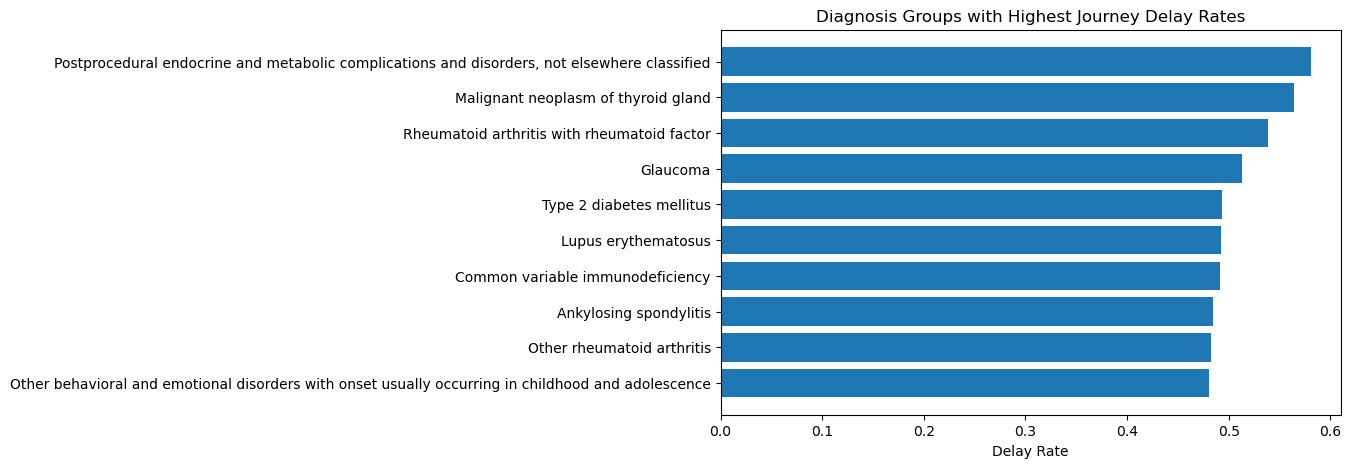

In [239]:
top_diag = diag_summary.sort_values('delay_rate', ascending=False).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(top_diag.index, top_diag['delay_rate'])
plt.xlabel('Delay Rate')
plt.title('Diagnosis Groups with Highest Journey Delay Rates')
plt.gca().invert_yaxis()
plt.show()

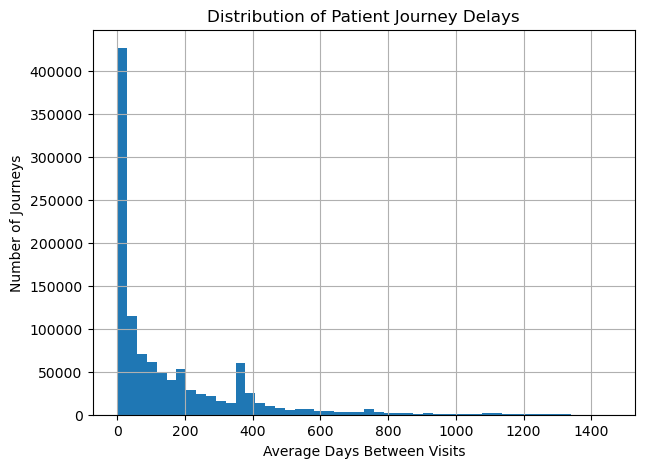

In [241]:
plt.figure(figsize=(7,5))

journeys['avg_gap'].hist(bins=50)

plt.xlabel('Average Days Between Visits')
plt.ylabel('Number of Journeys')
plt.title('Distribution of Patient Journey Delays')

plt.show()

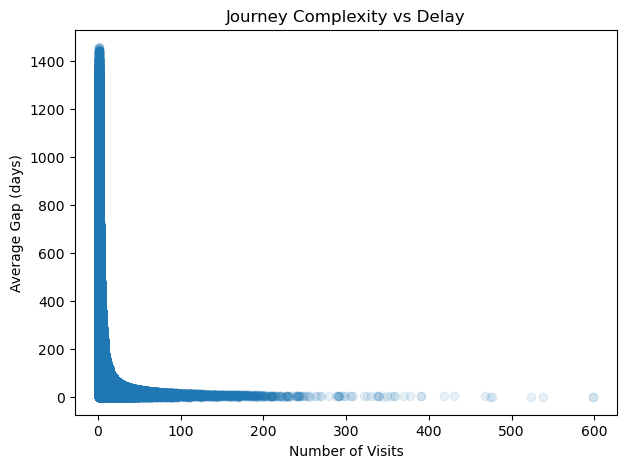

In [243]:
plt.figure(figsize=(7,5))

plt.scatter(
    journeys['visits'],
    journeys['avg_gap'],
    alpha=0.1
)

plt.xlabel('Number of Visits')
plt.ylabel('Average Gap (days)')
plt.title('Journey Complexity vs Delay')

plt.show()

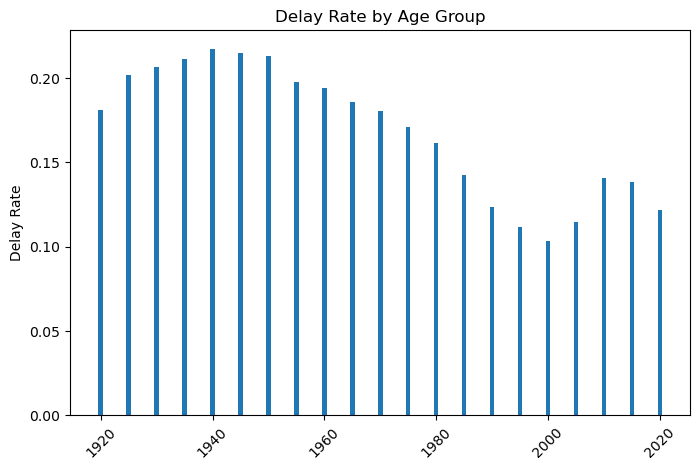

In [245]:
age_delay = journeys.groupby('PatientBirthYearBin_x')['delayed'].mean()

plt.figure(figsize=(8,5))

plt.bar(age_delay.index, age_delay.values)

plt.xticks(rotation=45)
plt.ylabel('Delay Rate')
plt.title('Delay Rate by Age Group')

plt.show()

In [247]:
journeys.groupby('delayed').agg({
    'visits':'mean',
    'num_departments':'mean',
    'ed_visits':'mean',
    'avg_gap':'mean',
    'PatientDurableKey':'count'
})

,visits,num_departments,ed_visits,avg_gap,PatientDurableKey
delayed,,,,,
False,1.900635,1.234986,0.082118,14.819432,2687379
True,3.964065,1.809421,0.047672,282.977571,560099


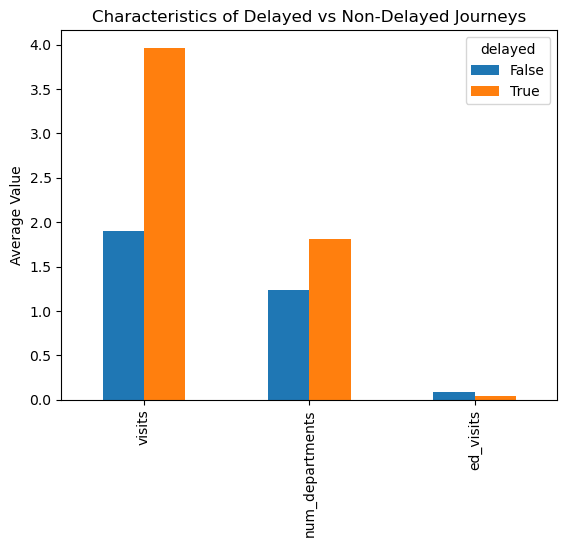

In [249]:
comparison = journeys.groupby('delayed')[[
    'visits',
    'num_departments',
    'ed_visits'
]].mean()

comparison.T.plot(kind='bar')

plt.title('Characteristics of Delayed vs Non-Delayed Journeys')
plt.ylabel('Average Value')

plt.show()